<a href="https://colab.research.google.com/github/khushi2460/Khushi/blob/main/reviewsir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔎 First 5 rows of dataset:
                                         review_text  review_label
0  I just readed 10 pages and I am in love with t...           1.0
1  I wondered why this book is called ' A good gi...           1.0
2                         OML. BUY IT. IT IS AMAZING           1.0
3                A wonderful book and nice delivery            1.0
4               The story is so good! I loved it sm.           1.0 

📊 Class distribution:
review_label
1.0    9
0.0    5
Name: count, dtype: int64 

✅ Accuracy: 0.3333333333333333

📑 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



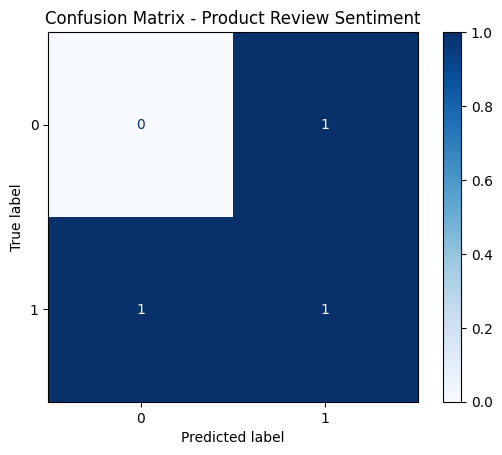


Review: 'This moisturizer is lightweight and keeps my skin hydrated all day.'
Predicted Sentiment: 1
Probabilities: {'0': np.float64(0.478), '1': np.float64(0.522)}

Review: 'The phone stopped working after two weeks. Very disappointed.'
Predicted Sentiment: 0
Probabilities: {'0': np.float64(0.56), '1': np.float64(0.44)}

Review: 'Decent quality for the price, but packaging could be better.'
Predicted Sentiment: 0
Probabilities: {'0': np.float64(0.531), '1': np.float64(0.469)}


In [ ]:
# 📦 Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# ------------------------------------------------
# 1️⃣ Load Product Review Dataset
# ------------------------------------------------
file_path = "/r.csv" # Changed to the new file name
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please upload the file to your Colab environment.")
else:
    df = pd.read_csv(file_path)  # Update with your actual file name

    # Assuming the column names are 'review_text' and 'review_label' based on previous interactions
    # If your r.csv has different column names, please let me know.
    if 'review_text' not in df.columns or 'review_label' not in df.columns:
        print(f"Error: The file '{file_path}' does not contain the expected columns 'review_text' and 'review_label'.")
    else:
        print("🔎 First 5 rows of dataset:")
        print(df.head(), "\n")

        print("📊 Class distribution:")
        print(df['review_label'].value_counts(), "\n")

        # Remove rows with NaN values in 'review_label' column
        df.dropna(subset=['review_label'], inplace=True)

        # Remove 'neutral' samples due to small dataset size and stratification issue
        df = df[df['review_label'] != 'neutral'].copy()

        # Convert review_label to integer type
        df['review_label'] = df['review_label'].astype(int)

        # ------------------------------------------------
        # 2️⃣ Preprocessing
        # ------------------------------------------------
        df['review_text'] = df['review_text'].str.lower().str.strip()

        # Encode sentiment labels
        le = LabelEncoder()
        y_enc = le.fit_transform(df['review_label'])

        # Prepare readable class names
        target_names = [str(c) for c in le.inverse_transform(le.classes_)] # Regenerate target_names

        # ------------------------------------------------
        # 3️⃣ Train/Test Split
        # ------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            df['review_text'], y_enc, test_size=0.2, random_state=42 # Removed stratify
        )

        # ------------------------------------------------
        # 4️⃣ Build Pipeline (TF-IDF + Logistic Regression)
        # ------------------------------------------------
        model = Pipeline([
            ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
        ])

        # ------------------------------------------------
        # 5️⃣ Train Model
        # ------------------------------------------------
        model.fit(X_train, y_train)

        # ------------------------------------------------
        # 6️⃣ Evaluate Model
        # ------------------------------------------------
        y_pred = model.predict(X_test)

        print("✅ Accuracy:", accuracy_score(y_test, y_pred))
        print("\n📑 Classification Report:\n",
              classification_report(y_test, y_pred, target_names=target_names))

        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                              display_labels=target_names, cmap="Blues")
        plt.title("Confusion Matrix - Product Review Sentiment")
        plt.show()

        # ------------------------------------------------
        # 7️⃣ Prediction Functions
        # ------------------------------------------------
        def predict_sentiment(texts):
            """Predict sentiment label(s) for product review(s)."""
            preds = model.predict(texts)
            return le.inverse_transform(preds)

        def predict_sentiment_proba(texts):
            """Return sentiment probabilities for product review(s)."""
            proba = model.predict_proba(texts)
            return [{cls: round(p, 3) for cls, p in zip(target_names, prob)} for prob in proba]

        # ------------------------------------------------
        # 8️⃣ Example Usage
        # ------------------------------------------------
        examples = [
            "This moisturizer is lightweight and keeps my skin hydrated all day.",
            "The phone stopped working after two weeks. Very disappointed.",
            "Decent quality for the price, but packaging could be better."
        ]

        for ex in examples:
            print(f"\nReview: '{ex}'")
            print("Predicted Sentiment:", predict_sentiment([ex])[0])
            print("Probabilities:", predict_sentiment_proba([ex])[0])